In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [18]:
import os
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.layers import AveragePooling2D,GlobalAveragePooling2D,Flatten,Dense,Conv2D,MaxPool2D,Dropout,concatenate
from tensorflow.keras import layers
from keras.models import Model
from tensorflow.keras.utils import to_categorical
from PIL import Image

In [3]:
data = []
labels = []
classes = 43 
cur_path = os.getcwd() 
for i in range(classes): 
    path = os. path.join(cur_path,'train', str(i)) 
    images = os.listdir(path) 
    for a in images: 
        try: 
            image = Image.open(path + '/' + a) 
            image = image.resize((224,224)) 
            image = np.array(image) 
            data.append(image) 
            labels.append(i) 
        except: 
            print("Error loading image") 
data = np.array(data)
labels = np.array(labels)

In [4]:
print(data.shape, labels.shape)

(39209, 224, 224, 3) (39209,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 224, 224, 3) (7842, 224, 224, 3) (31367,) (7842,)


In [7]:
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

In [8]:
from keras.layers import Input

In [13]:
def inception_module(x,
              filters_1x1,
              filters_3x3_reduce,
              filters_3x3,
              filters_5x5_reduce,
              filters_5x5,
              filters_pool):
    convo_1x1 = layers.Conv2D(filters_1x1, (1, 1), padding='same',activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(x)

    convo_3x3 = layers.Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    convo_3x3 = layers.Conv2D(filters_3x3, (3, 3), padding='same',activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(convo_3x3)

    convo_5x5 = layers.Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    convo_5x5 = layers.Conv2D(filters_5x5, (5, 5), padding='same',activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(convo_5x5)

    maxpool_3x3 = layers.MaxPool2D((3, 3), strides=(1, 1), padding='same')(x)
    convo_maxp_1x1 = layers.Conv2D(filters_pool, (1, 1), padding='same',activation='relu',kernel_initializer=kernel_init, bias_initializer=bias_init)(maxpool_3x3)
    
    return tf.concat([convo_1x1,convo_3x3,convo_5x5,convo_maxp_1x1], axis=3)

In [32]:
kernel_init = keras.initializers.glorot_uniform()
bias_init = keras.initializers.Constant(value=0.2)

input_layer = Input(shape=(224, 224, 3))

x = layers.Conv2D(filters = 64, kernel_size=(7, 7), padding='same', strides=(2, 2), activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(input_layer)
x = layers.MaxPool2D(pool_size = (3, 3), padding='same', strides=(2, 2))(x)
x = layers.Conv2D(filters = 64,kernel_size = (1, 1), padding='same', strides=(1, 1), activation='relu')(x)
x = layers.Conv2D(filters = 192,kernel_size = (3, 3), padding='same', strides=(1, 1), activation='relu')(x)
x = layers.MaxPool2D(pool_size = (3, 3), padding='same', strides=(2, 2))(x)

x = inception_module(x,
                     filters_1x1=64,
                     filters_3x3_reduce=96,
                     filters_3x3=128,
                     filters_5x5_reduce=16,
                     filters_5x5=32,
                     filters_pool=32)
x = inception_module(x,
                     filters_1x1=128,
                     filters_3x3_reduce=128,
                     filters_3x3=192,
                     filters_5x5_reduce=32,
                     filters_5x5=96,
                     filters_pool=64)
x = layers.MaxPool2D(pool_size=(3, 3),padding='same', strides=(2, 2))(x)
x = inception_module(x,
                     filters_1x1=192,
                     filters_3x3_reduce=96,
                     filters_3x3=208,
                     filters_5x5_reduce=16,
                     filters_5x5=48,
                     filters_pool=64)
x1 = layers.AveragePooling2D((5, 5), strides=3)(x)
x1 = layers.Conv2D(filters= 128,kernel_size = (1, 1), padding='same', activation='relu')(x1)
x1 = layers.Flatten()(x1)
x1 = layers.Dense(1024, activation='relu')(x1)
x1 = layers.Dropout(0.7)(x1)
x1 = layers.Dense(43, activation='softmax')(x1)
x = inception_module(x,
                     filters_1x1=160,
                     filters_3x3_reduce=112,
                     filters_3x3=224,
                     filters_5x5_reduce=24,
                     filters_5x5=64,
                     filters_pool=64)
x = inception_module(x,
                     filters_1x1=128,
                     filters_3x3_reduce=128,
                     filters_3x3=256,
                     filters_5x5_reduce=24,
                     filters_5x5=64,
                     filters_pool=64)
x = inception_module(x,
                     filters_1x1=112,
                     filters_3x3_reduce=144,
                     filters_3x3=288,
                     filters_5x5_reduce=32,
                     filters_5x5=64,
                     filters_pool=64)

x2 = layers.AveragePooling2D((5, 5), strides=3)(x)
x2 = layers.Conv2D(filters =128, kernel_size = (1, 1), padding='same', activation='relu')(x2)
x2 = layers.Flatten()(x2)
x2 = layers.Dense(1024, activation='relu')(x2)
x2 = layers.Dropout(0.7)(x2)
x2 = layers.Dense(43, activation='softmax',)(x2)
x = inception_module(x,
                     filters_1x1=256,
                     filters_3x3_reduce=160,
                     filters_3x3=320,
                     filters_5x5_reduce=32,
                     filters_5x5=128,
                     filters_pool=128)
x = layers.MaxPool2D((3, 3), padding='same', strides=(2, 2))(x)
x = inception_module(x,
                     filters_1x1=256,
                     filters_3x3_reduce=160,
                     filters_3x3=320,
                     filters_5x5_reduce=32,
                     filters_5x5=128,
                     filters_pool=128)
x = inception_module(x,
                     filters_1x1=384,
                     filters_3x3_reduce=192,
                     filters_3x3=384,
                     filters_5x5_reduce=48,
                     filters_5x5=128,
                     filters_pool=128)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(43, activation='softmax')(x)

In [33]:
model = Model(input_layer, [x, x1, x2])
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_108 (Conv2D)            (None, 112, 112, 64  9472        ['input_6[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d_28 (MaxPooling2D  (None, 56, 56, 64)  0           ['conv2d_108[0][0]']             
 )                                                                                          

                                                                                                  
 conv2d_133 (Conv2D)            (None, 14, 14, 24)   12312       ['tf.concat_17[0][0]']           
                                                                                                  
 max_pooling2d_34 (MaxPooling2D  (None, 14, 14, 512)  0          ['tf.concat_17[0][0]']           
 )                                                                                                
                                                                                                  
 conv2d_130 (Conv2D)            (None, 14, 14, 160)  82080       ['tf.concat_17[0][0]']           
                                                                                                  
 conv2d_132 (Conv2D)            (None, 14, 14, 224)  226016      ['conv2d_131[0][0]']             
                                                                                                  
 conv2d_13

                                                                                                  
 conv2d_158 (Conv2D)            (None, 7, 7, 32)     26656       ['max_pooling2d_38[0][0]']       
                                                                                                  
 max_pooling2d_39 (MaxPooling2D  (None, 7, 7, 832)   0           ['max_pooling2d_38[0][0]']       
 )                                                                                                
                                                                                                  
 conv2d_155 (Conv2D)            (None, 7, 7, 256)    213248      ['max_pooling2d_38[0][0]']       
                                                                                                  
 conv2d_157 (Conv2D)            (None, 7, 7, 320)    461120      ['conv2d_156[0][0]']             
                                                                                                  
 conv2d_15

In [36]:
epochs = 15
initial_lrate = 0.01

def decay(epoch, steps=100):
    initial_lrate = 0.01
    drop = 0.96
    epochs_drop = 8
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

sgd = tf.optimizers.SGD(lr=initial_lrate, momentum=0.9, nesterov=False)

lr_sc = LearningRateScheduler(decay, verbose=1)

model.compile(loss=['categorical_crossentropy', 'categorical_crossentropy', 'categorical_crossentropy'], loss_weights=[1, 0.3, 0.3], optimizer=sgd, metrics=['accuracy'])

In [37]:
history = model.fit(X_train, [y_train, y_train, y_train], validation_data=(X_test, [y_test, y_test, y_test]), epochs=epochs, batch_size=128, callbacks=[lr_sc])


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/15
246/246 [==============================] - 4335s 18s/step - loss: 5.6092 - dense_11_loss: 3.4733 - dense_8_loss: 3.6073 - dense_10_loss: 3.5123 - dense_11_accuracy: 0.0681 - dense_8_accuracy: 0.0543 - dense_10_accuracy: 0.0660 - val_loss: 5.6631 - val_dense_11_loss: 3.5586 - val_dense_8_loss: 3.4825 - val_dense_10_loss: 3.5324 - val_dense_11_accuracy: 0.0645 - val_dense_8_accuracy: 0.0599 - val_dense_10_accuracy: 0.0786 - lr: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/15
246/246 [==============================] - 4375s 18s/step - loss: 5.1063 - dense_11_loss: 3.1841 - dense_8_loss: 3.2517 - dense_10_loss: 3.1555 - dense_11_accuracy: 0.1193 - dense_8_accuracy: 0.1366 - dense_10_accuracy: 0.1420 - val_loss: 4.5665 - val_dense_11_loss: 2.9630 - val_dense_8_loss: 2.6921 - val_dense_10_loss: 2.6529 - val_dense_11_accuracy: 0.1428 - val_dense_8_accuracy: 0.2864 - val_dense_10_accuracy

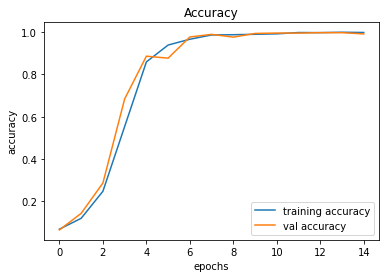

In [39]:
plt.figure(0)
plt.plot(history.history['dense_11_accuracy'], label='training accuracy')
plt.plot(history.history['val_dense_11_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

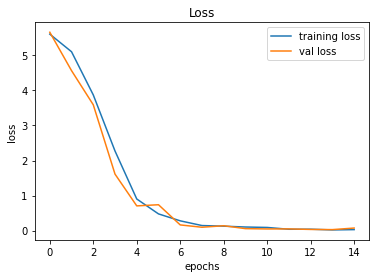

In [40]:
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [41]:
from sklearn.metrics import accuracy_score
y_test = pd.read_csv('Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   image = Image.open(img)
   image = image.resize((224,224))
   data.append(np.array(image))
X_test=np.array(data)

In [52]:
print(X_test)

[[[[115. 137. 172.]
   [115. 137. 172.]
   [115. 137. 172.]
   ...
   [ 58.  77.  99.]
   [ 56.  75.  97.]
   [ 55.  74.  96.]]

  [[115. 138. 173.]
   [115. 138. 173.]
   [115. 138. 173.]
   ...
   [ 61.  80. 103.]
   [ 59.  78. 100.]
   [ 58.  77.  99.]]

  [[115. 138. 173.]
   [115. 138. 173.]
   [115. 138. 173.]
   ...
   [ 67.  86. 110.]
   [ 65.  84. 108.]
   [ 65.  84. 107.]]

  ...

  [[112. 135. 168.]
   [112. 135. 168.]
   [112. 135. 168.]
   ...
   [115. 140. 172.]
   [115. 140. 172.]
   [115. 140. 172.]]

  [[112. 135. 168.]
   [112. 135. 168.]
   [112. 135. 168.]
   ...
   [115. 140. 172.]
   [115. 140. 172.]
   [115. 140. 172.]]

  [[112. 135. 168.]
   [112. 135. 168.]
   [112. 135. 168.]
   ...
   [115. 140. 172.]
   [115. 140. 172.]
   [115. 140. 172.]]]


 [[[ 52.  67.  62.]
   [ 53.  69.  62.]
   [ 55.  69.  62.]
   ...
   [ 72.  69.  69.]
   [ 73.  69.  69.]
   [ 73.  69.  69.]]

  [[ 52.  67.  61.]
   [ 53.  68.  61.]
   [ 55.  69.  61.]
   ...
   [ 72.  69.  69.]
 

In [60]:
X_test.shape
X_test.dtype

dtype('float32')

In [58]:
print(labels)
labels.shape


[16  1 38 ...  6  7 10]


(12630,)

In [62]:
labels = to_categorical(labels, 43)

In [63]:
model.evaluate(X_test,labels)

395/395 [==============================] - 440s 1s/step - loss: 0.5014 - dense_11_loss: 0.3268 - dense_8_loss: 0.2922 - dense_10_loss: 0.2898 - dense_11_accuracy: 0.9492 - dense_8_accuracy: 0.9537 - dense_10_accuracy: 0.9549


[0.5013995170593262,
 0.32680025696754456,
 0.2921912372112274,
 0.2898062467575073,
 0.9492478370666504,
 0.9536817073822021,
 0.9548693299293518]

In [64]:
model.save('traffic_classifier_googLeNet.h5')